In [25]:
import h5py
import math
import csv
import numpy as np
import matplotlib.pyplot as plt
from math import e
import statistics as st
import cmath
import scipy
import scipy.stats as ss
import random
import seaborn as sns
import pandas as pd
import emcee
import corner
import numpy.ma as ma
from scipy.interpolate import interp1d
import pickle
from scipy import interpolate
import scipy.constants as const

In [26]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [27]:
with open('results_sky_62_a1s1_simdata.pkl', 'rb') as f:

    result_loaded= pickle.load(f) # deserialize using load()
    

In [28]:
seed=result_loaded["seed"]
req_freq=result_loaded["req_freq"]#----------------- Frequencies
samples=result_loaded["samples"]#------------------- Flattened samples after burn
full_samples=result_loaded["full_samples"]#--------- All samples
best_fit=result_loaded["best_fit"]#----------------- Max likelihood values
parameter_names=result_loaded["param_names"]#------- Param names
true_params=result_loaded["true_params"]#----------- Actual Parameter values
S11_params=result_loaded["S11_params"]
Tmeas_Actual=result_loaded["Real Data"]#------------ Actual TMeas
sig21cm=result_loaded["sig21cm"]#------------------- 21cm Signal
#Mean_AF=result_loaded["Mean Acceptance Factor"]#---- Mean Acceptance Factor
#Auto_Corr_time=result_loaded["Auto corr time"]#----- Mean Corr Time

## Corner Plot

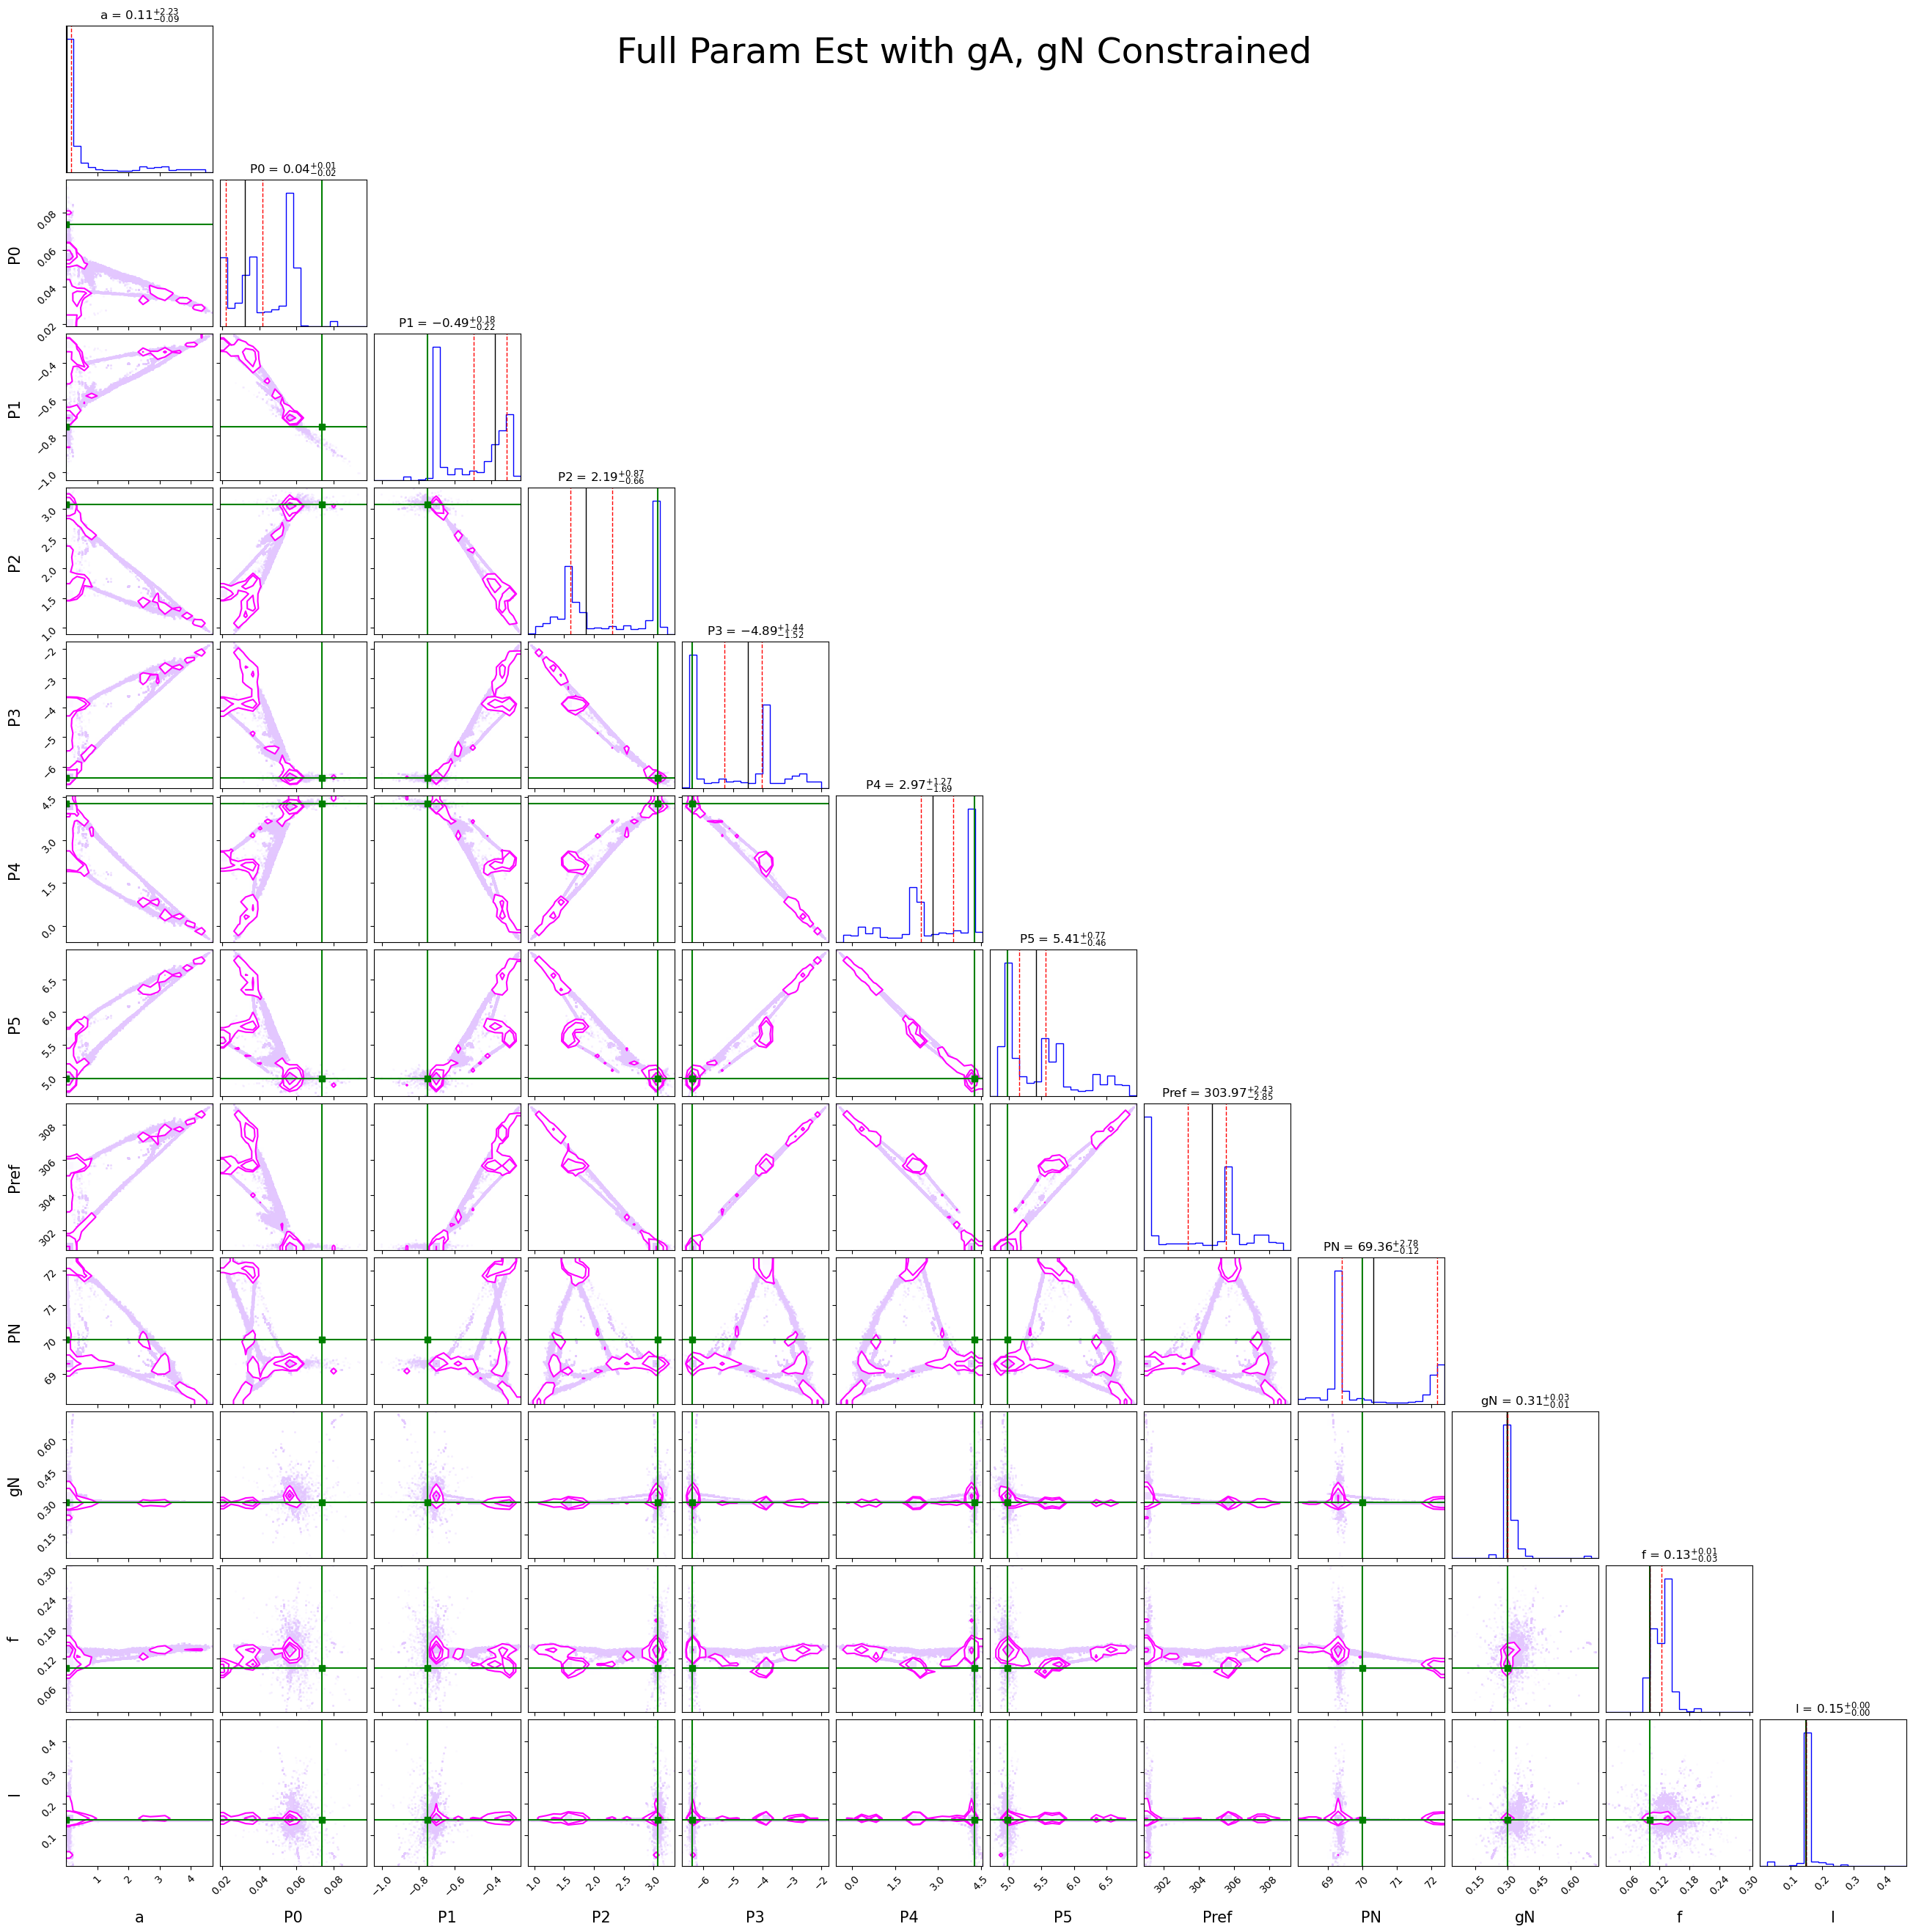

In [29]:
pastel_color ="#E3C6FF"
a, PSky_cc, Pref, PN, gN, f, l=true_params
#print(type(PSky_cc_true), type(Pref), type(PN), type(gN), type(f), type(l))
P0,P1,P2,P3,P4,P5=PSky_cc
True_values=a, P0,P1,P2,P3,P4,P5, Pref, PN, gN, f, l 
flat_full = full_samples.reshape(-1, full_samples.shape[-1])
fig = corner.corner(flat_full, labels=parameter_names, show_titles=True, 
                    truths=True_values, 
                    color=pastel_color,  # Change color of the contour and histograms
                    hist_kwargs={"color": "#E3C6FF", "edgecolor": "b"},  # Set histogram color
                    label_kwargs={"fontsize":15}, #set label size
                    contour_kwargs={"colors": ["magenta"]},
                    truth_color="green" ) # Color for the true parameter values)
plt.suptitle("Full Param Est with gA, gN Constrained", fontsize=35)
#plt.savefig('/home/saurabhs/Documents/gopi/Saras_Model/RLC_Full_gA_1m_.png', dpi=300)
#plt.savefig('Art.png')

# Add 1-sigma lines to each marginal histogram
n_dim = samples.shape[1]

axes = np.array(fig.axes).reshape((n_dim, n_dim))

for i in range(n_dim):
    ax = axes[i, i]
    q16, q50, q84 = np.percentile(samples[:, i], [16, 50, 84])
    ax.axvline(q16, color="red", linestyle="--", linewidth=1)
    ax.axvline(q84, color="red", linestyle="--", linewidth=1)
    ax.axvline(q50, color="black", linestyle="-", linewidth=1)  # optional: median


plt.show()

## KDE plots for each parameter

1
2
3
4
5
6


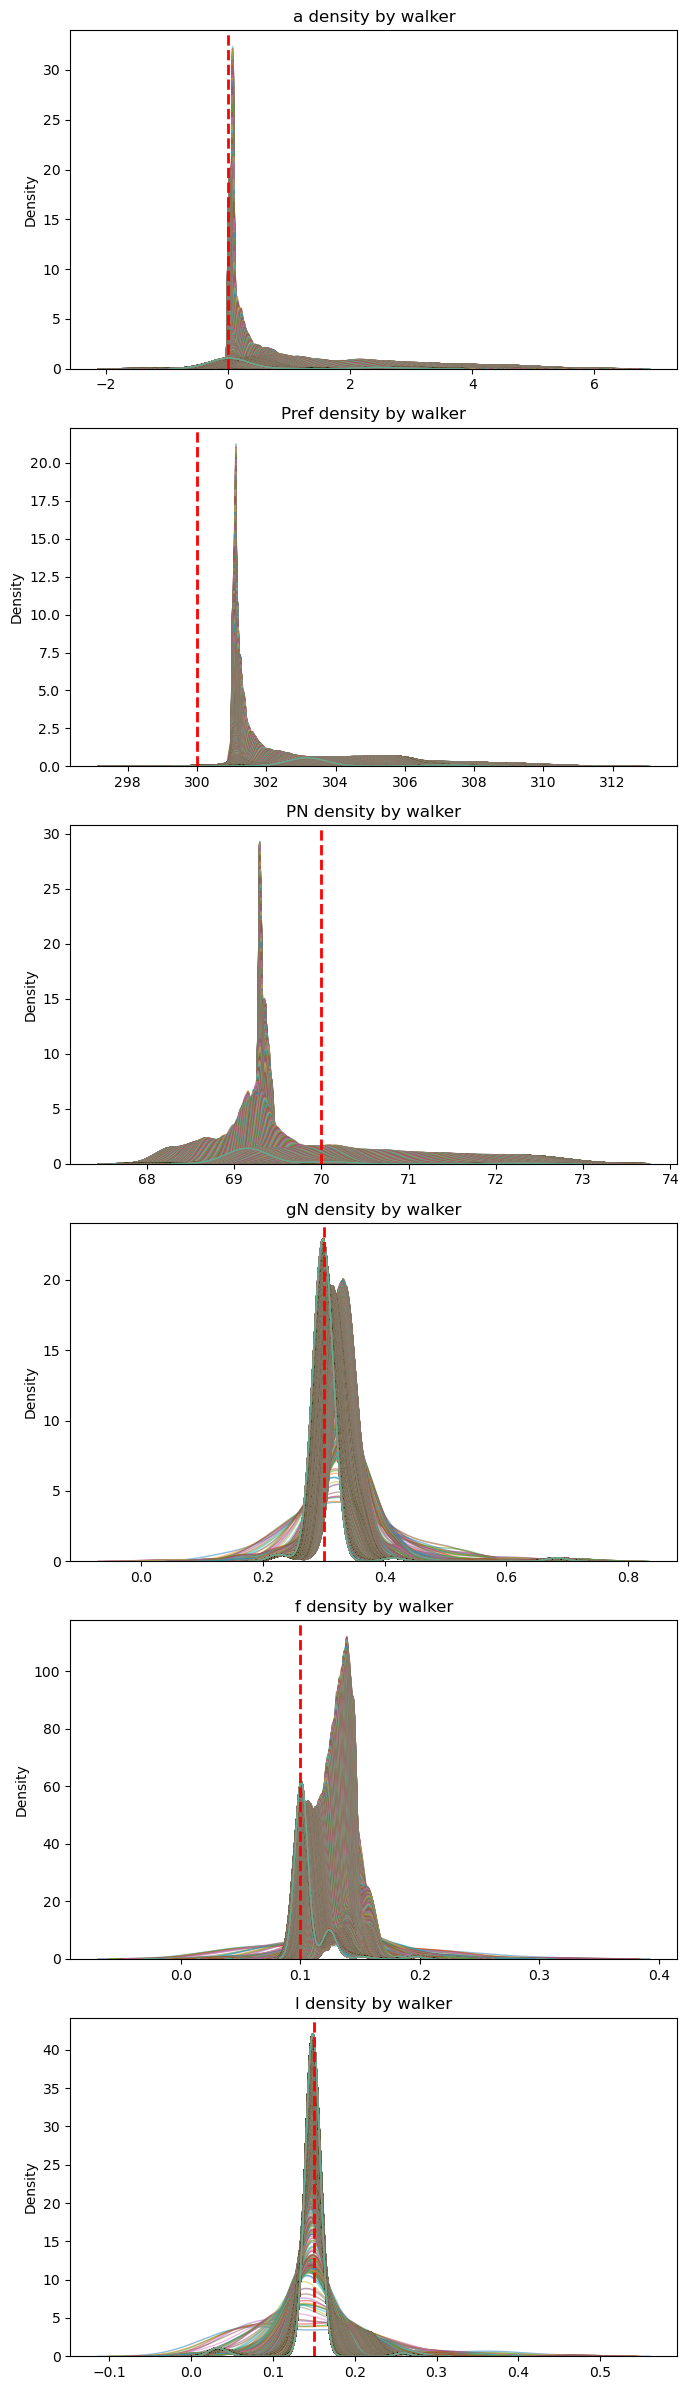

In [30]:

n_steps=full_samples.shape[0]
fig, axes = plt.subplots(n_dim-6, 1, figsize=(7, 2*n_dim))
j=0
for i in range(n_dim):
    if i>0 and i<7:
        pass
    else:
        for s in range(n_steps):
            sns.kdeplot(full_samples[s, :, i], ax=axes[j], alpha=0.5, lw=1)
        p=parameter_names[i]
        axes[j].set_title(f"{p} density by walker")
        axes[j].axvline(x=True_values[i], color='r', linestyle='--', linewidth=2, label='True')
        j=j+1

plt.tight_layout()
plt.show()

In [31]:
flat_full = full_samples.reshape(-1, full_samples.shape[-1])
full_samples.shape

(5000, 100, 12)

### Trace Plots

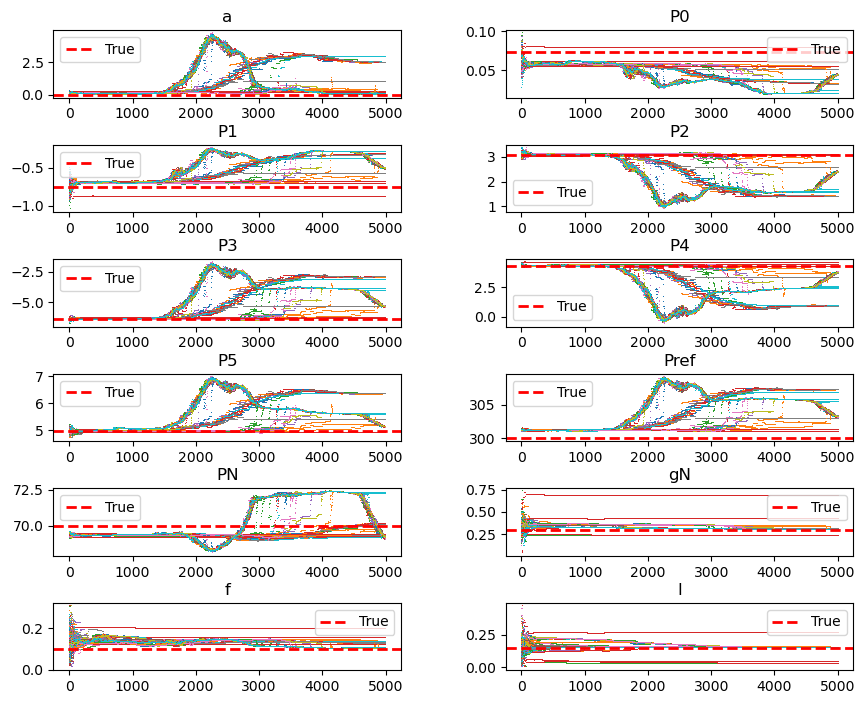

In [32]:
#walker plots
fig, axes = plt.subplots(6, 2, figsize=(10, 8))

plt.subplots_adjust(
    left=0.1,    # Left margin
    right=0.9,   # Right margin
    bottom=0.1,  # Bottom margin
    top=0.9,     # Top margin
    wspace=0.3,  # Width space between columns (fraction of average axis width)
    hspace=0.7   # Height space between rows (fraction of average axis height)
)


axes[0,0].plot(full_samples[:,:,0],',')
axes[0,0].set_title('a')
axes[0,0].axhline(y=True_values[0], color='r', linestyle='--', linewidth=2, label='True')
axes[0,0].legend()

axes[0,1].plot(full_samples[:,:,1],',')
axes[0,1].set_title('P0')
axes[0,1].axhline(y=True_values[1], color='r', linestyle='--', linewidth=2, label='True')
axes[0,1].legend()

axes[1,0].plot(full_samples[:,:,2],',')
axes[1,0].set_title('P1')
axes[1,0].axhline(y=True_values[2], color='r', linestyle='--', linewidth=2, label='True')
axes[1,0].legend()

axes[1,1].plot(full_samples[:,:,3],',')
axes[1,1].set_title('P2')
axes[1,1].axhline(y=True_values[3], color='r', linestyle='--', linewidth=2, label='True')
axes[1,1].legend()

axes[2,0].plot(full_samples[:,:,4],',')
axes[2,0].set_title('P3')
axes[2,0].axhline(y=True_values[4], color='r', linestyle='--', linewidth=2, label='True')
axes[2,0].legend()

axes[2,1].plot(full_samples[:,:,5],',')
axes[2,1].set_title('P4')
axes[2,1].axhline(y=True_values[5], color='r', linestyle='--', linewidth=2, label='True')
axes[2,1].legend()

axes[3,0].plot(full_samples[:,:,6],',')
axes[3,0].set_title('P5')
axes[3,0].axhline(y=True_values[6], color='r', linestyle='--', linewidth=2, label='True')
axes[3,0].legend()

axes[3,1].plot(full_samples[:,:,7],',')
axes[3,1].set_title('Pref')
axes[3,1].axhline(y=True_values[7], color='r', linestyle='--', linewidth=2, label='True')
axes[3,1].legend()

axes[4,0].plot(full_samples[:,:,8],',')
axes[4,0].set_title('PN')
axes[4,0].axhline(y=True_values[8], color='r', linestyle='--', linewidth=2, label='True')
axes[4,0].legend()

axes[4,1].plot(full_samples[:,:,9],',')
axes[4,1].set_title('gN')
axes[4,1].axhline(y=True_values[9], color='r', linestyle='--', linewidth=2, label='True')
axes[4,1].legend()

axes[5,0].plot(full_samples[:,:,10],',')
axes[5,0].set_title('f')
axes[5,0].axhline(y=True_values[10], color='r', linestyle='--', linewidth=2, label='True')
axes[5,0].legend()

axes[5,1].plot(full_samples[:,:,11],',')
axes[5,1].set_title('l')
axes[5,1].axhline(y=True_values[11], color='r', linestyle='--', linewidth=2, label='True')
axes[5,1].legend()

### Model Function

In [33]:
def Compute_Tmeas_Sky(PA, Pref, S11_params, PN, gamma_N, f, l, v): 
    req_freq=np.array(v)
    A = np.zeros_like(req_freq, dtype=float)
    B = np.zeros_like(req_freq, dtype=float)
    C = np.zeros_like(req_freq, dtype=float)
    l=l
    itr=9
    Tmeas=[]
    phi_A=0
    phi_N=0
    phi_f=0
    P_ref=Pref
    c=const.c
    
    p0,p1,p2,p3,p4,p5,p6=S11_params
    gamma_A=np.polyval([p0*1e-11, p1*1e-9, p2*1e-06, p3*1e-04, p4*1e-03, p5*1e-1, p6],req_freq)
    
    #PSky_coeffs=PSky_coeffs
    
    phi=(4*math.pi*(req_freq*1e6)*l)/(0.7*c)
    #print(phi.size)
    for n in range(itr):
        # For A term: l index sum
        l_values = np.arange(n + 1)
        sum_l = np.sum(np.cos((2 * l_values[:, None] - n) * (phi_N + phi_A + phi)), axis=0)
        #print(sum_l.size)
        # For C term: c index sum (same structure as A)
        c_values = np.arange(n + 1)
        sum_c = np.sum(np.cos((2 * c_values[:, None] - n) * (phi_N + phi_A + phi)), axis=0)

        # Powers
        gammaA_pow_n = np.abs(gamma_A)**n
        gammaN_pow_n = np.abs(gamma_N)**n

        # A term update
        A += gammaA_pow_n * gammaN_pow_n * sum_l

        # B term update
        B += 2 * np.abs(f) * (np.abs(gamma_A)**(n + 1)) * gammaN_pow_n * \
             np.cos(phi_f + (n + 1)*(phi_A + phi) + n*phi_N)

        # C term update
        C += gammaA_pow_n * gammaN_pow_n * sum_c

    #Tmeas = (PA * A - Pref) + PN * (B + (np.abs(f)**2) * (np.abs(gamma_A)**2) * A)
    
    Tmeas = (PA*(1-np.abs(gamma_A)**2) * A - Pref)+ PN * (B + (np.abs(f)**2) * (np.abs(gamma_A)**2) * C)

    return Tmeas

In [34]:
"""
## No. of iteration test
i=9
alpha, PA, Pref, PN, gN, f, l = [2.5,200,300,70,0.3,0.1,0.15]
p0, p1, p2, p3, p4, p5, p6= [-1.20013123,  6.04175607, -1.24392165,  1.34628657,\
                              -7.91822329,  2.22071051, -1.40950769]
T1=Compute_Tmeas_Sky(alpha, PA, Pref, p0, p1, p2, p3, p4, p5, p6, PN, gN, f, l ,i,req_freq)
T2=Compute_Tmeas_Sky(alpha, PA, Pref, p0, p1, p2, p3, p4, p5, p6, PN, gN, f, l ,i+1,req_freq)
r=T1-T2
plt.plot(req_freq,r)
"""

'\n## No. of iteration test\ni=9\nalpha, PA, Pref, PN, gN, f, l = [2.5,200,300,70,0.3,0.1,0.15]\np0, p1, p2, p3, p4, p5, p6= [-1.20013123,  6.04175607, -1.24392165,  1.34628657,                              -7.91822329,  2.22071051, -1.40950769]\nT1=Compute_Tmeas_Sky(alpha, PA, Pref, p0, p1, p2, p3, p4, p5, p6, PN, gN, f, l ,i,req_freq)\nT2=Compute_Tmeas_Sky(alpha, PA, Pref, p0, p1, p2, p3, p4, p5, p6, PN, gN, f, l ,i+1,req_freq)\nr=T1-T2\nplt.plot(req_freq,r)\n'

### TMeas observed vs TMeas expected

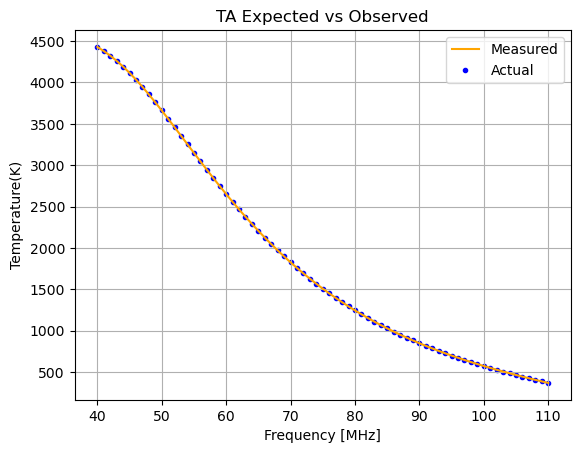

In [35]:
a, P0,P1,P2,P3,P4,P5, Pref, PN, gN, f, l = best_fit
PSky_cc_best=[P0,P1,P2,P3,P4,P5]
PSky_log=np.polyval([P0, P1, P2, P3, P4, P5],np.log10(req_freq))
PA=np.power(10.0, PSky_log, dtype=np.float64)
p0, p1, p2, p3, p4, p5, p6 = S11_params

## Signal Estimated based on the best fit
Tbest=Compute_Tmeas_Sky(PA, Pref, S11_params, PN, gN, f, l,req_freq)+a*sig21cm

## Actual Signal
TMeas_exp=Tmeas_Actual
plt.plot(req_freq, Tbest, label='Measured', color='orange')
plt.plot(req_freq, TMeas_exp,'.b',label='Actual',zorder=-1)
plt.title("TA Expected vs Observed")
plt.xlabel("Frequency [MHz]")
plt.ylabel("Temperature(K)")
plt.legend()
plt.grid(True)
plt.show()

### PSky Expected vs Observed

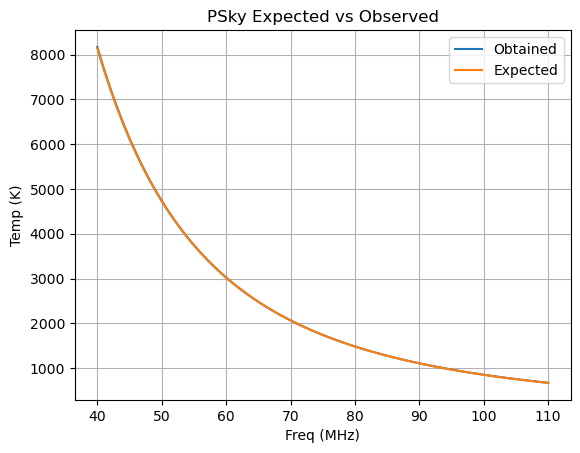

In [36]:
PSky_log_t =np.polyval(PSky_cc, np.log10(req_freq))
PSky_t=np.power(10.0, PSky_log_t, dtype=np.float64)
plt.plot(req_freq, PA, label="Obtained")
plt.plot(req_freq, PSky_t, label="Expected")
plt.title("PSky Expected vs Observed")
plt.xlabel("Freq (MHz)")
plt.ylabel("Temp (K)")
plt.legend()
plt.grid()

### Residuals

Residuals RMSE: 0.0034234392298277514


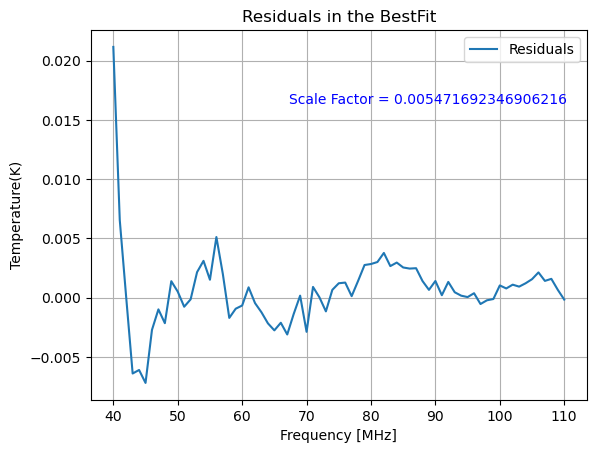

In [37]:
recovery=(Tbest-TMeas_exp)

#good_ind = ~recovery.mask ## considering only the non-masked indices

#plt.plot(req_freq[good_ind], recovery[good_ind],label="Residuals" )
plt.plot(req_freq, recovery, label="Residuals")

#plt.plot(req_freq,sig21cm,label="21cm Signal")
plt.text(0.4, 0.8, f"Scale Factor = {a}", transform=plt.gca().transAxes,fontsize=10, color='blue')
plt.title("Residuals in the BestFit")
plt.xlabel("Frequency [MHz]")
plt.ylabel("Temperature(K)")
plt.grid(True)
plt.legend()
print(f"Residuals RMSE: {np.sqrt(np.mean((recovery)**2))}")
plt.show()


### Estimating Residuals for every sample

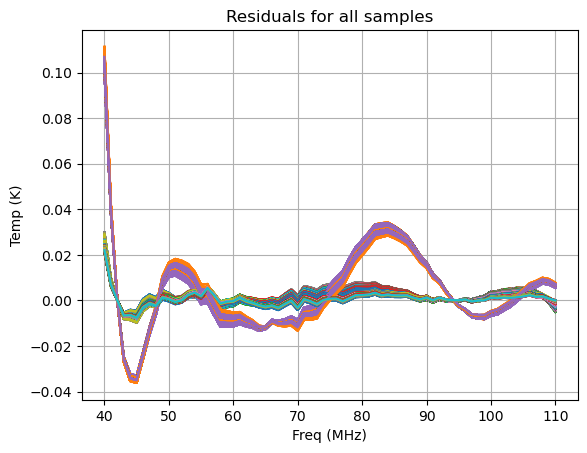

In [38]:
reduced_samples_sky = samples
sample_indices = np.arange(0, len(reduced_samples_sky),10)
TA= np.zeros((len(sample_indices), len(req_freq)))
res= np.zeros((len(sample_indices), len(req_freq)))
PA_sample= np.zeros((len(sample_indices), len(req_freq)))

for jj, ii in enumerate(sample_indices):
    a, P0,P1,P2,P3,P4,P5, Pref, PN, gN, f, l= reduced_samples_sky[ii]
    #PSky_cc_sample=[P0,P1,P2,P3,P4,P5]
    PSky_log_sample=np.polyval([P0, P1, P2, P3, P4, P5],np.log10(req_freq))
    PA_sample[jj]=np.power(10.0, PSky_log_sample, dtype=np.float64)
    TA_obs=Compute_Tmeas_Sky(PA_sample[jj], Pref, S11_params, PN, gN, f, l,req_freq)+a*sig21cm
    TA_obs=np.array(TA_obs)
    TA[jj] = TA_obs
    res[jj]= (TA_obs-TMeas_exp)

plt.plot(req_freq,res.T)
plt.title("Residuals for all samples")
plt.xlabel("Freq (MHz)")
plt.ylabel("Temp (K)")
plt.grid(True)
plt.show()

### PSky for all samples

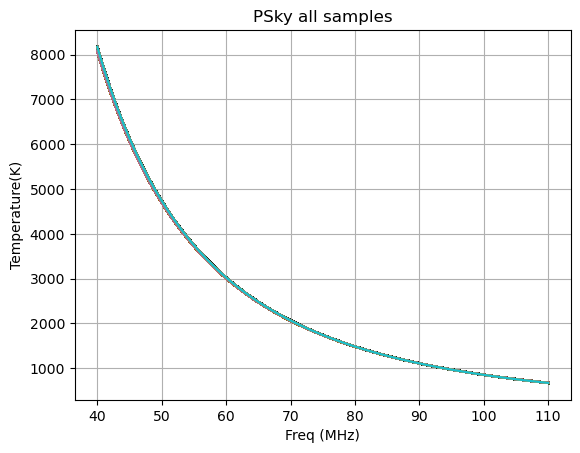

In [39]:
# PSky for all samples
plt.plot(req_freq,PA_sample.T)
plt.title("PSky all samples")
plt.xlabel("Freq (MHz)")
plt.ylabel("Temperature(K)")
plt.grid(True)
plt.show()

In [40]:
TA_mean=np.median(TA, axis=0) ## Mean of all samples
residuals_of_mean=TA_mean-TMeas_exp ## Residual for the mean of all samples
mean_of_residuals=np.median(res, axis=0)

In [41]:
"""
## Removing masks
freq=req_freq[good_ind]
recovery=recovery[good_ind]
residuals_of_mean=residuals_of_mean[good_ind]
mean_of_residuals=mean_of_residuals[good_ind]
"""

'\n## Removing masks\nfreq=req_freq[good_ind]\nrecovery=recovery[good_ind]\nresiduals_of_mean=residuals_of_mean[good_ind]\nmean_of_residuals=mean_of_residuals[good_ind]\n'

### Residuals of Best Fit vs Mean of all Residuals vs Residuals of the Mean of Samples

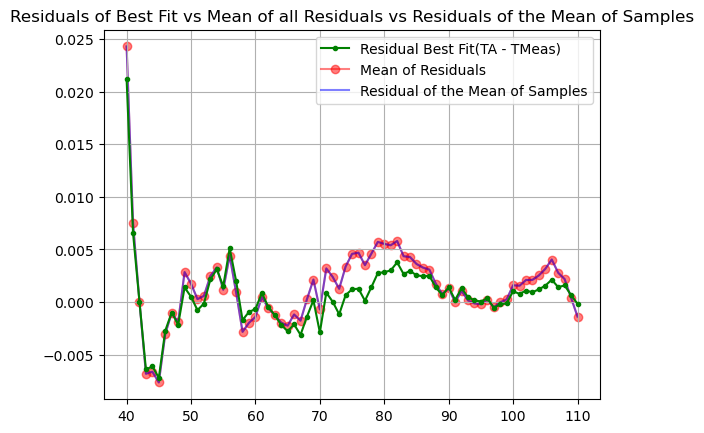

In [42]:
plt.plot(req_freq, recovery, label='Residual Best Fit(TA - TMeas)', color='green', marker='.')
plt.plot(req_freq,mean_of_residuals, alpha=0.5, label='Mean of Residuals', color='red',marker='o',zorder=-1)
plt.plot(req_freq,residuals_of_mean, alpha=0.5, label='Residual of the Mean of Samples', color='blue', zorder=1)
plt.legend()
plt.title('Residuals of Best Fit vs Mean of all Residuals vs Residuals of the Mean of Samples')
plt.grid()
plt.show()

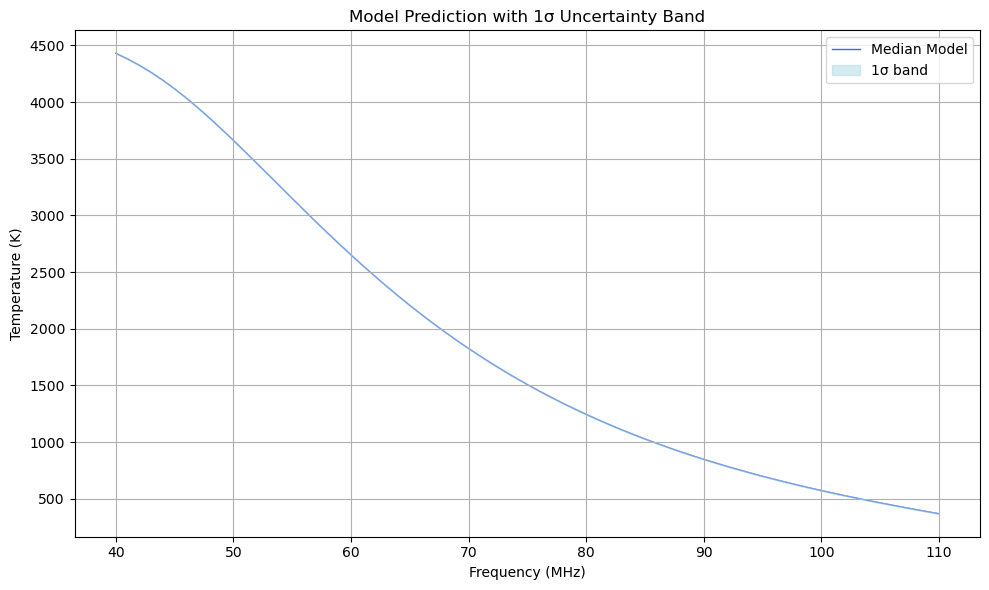

In [43]:
# Compute percentiles for 1-sigma band
TA_lower = np.percentile(TA, 16, axis=0)
TA_upper = np.percentile(TA, 84, axis=0)
TA_median = np.percentile(TA, 50, axis=0)

# Plot
plt.figure(figsize=(10, 6))
#plt.plot(req_freq, TA_true, label='Measured (TMeas)', color='black', marker='.', linewidth=1, zorder=1)
plt.plot(req_freq, TA_median, label='Median Model', color='royalblue', linewidth=1, zorder=-1)
plt.fill_between(req_freq, TA_lower, TA_upper, color='lightblue', alpha=0.5, label='1σ band')

plt.xlabel("Frequency (MHz)")
plt.ylabel("Temperature (K)")
plt.title("Model Prediction with 1σ Uncertainty Band")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()